2.3.3 Tensor dot

In [ ]:
import numpy as np

In [ ]:
x= np.array([[1,2,3],[4,5,6]])
y=np.array([7,8,9])

In [ ]:
print(y.shape[0])

3


In [ ]:
def naive__matrix_vector_dot(x,y):
  assert len(x.shape)==2
  assert len(y.shape)==1
  assert x.shape[1]== y.shape[0]

  z=np.zeros(x.shape[0])
  for i in range (x.shape[0]):
    for j in range (x.shape[1]):
      z[i] +=x[i,j]*y[j]
  return z

In [ ]:
z = naive__matrix_vector_dot(x,y)
print(z)

[ 50. 122.]


In [ ]:
t = np.dot(x, y)
t

NameError: ignored

In [ ]:
q =np.array([ # 1st level Array (Outer)
    [ # 2nd level Array
        [[1, 2, 20], [3, 4,20]], # 3rd level arrays, containing 2 4th level arrays
        [[5, 6, 20], [7, 8, 20]]
    ],
    [ # 2nd Level array
        [[9, 10, 20], [11, 12, 20]],
        [[13, 14, 20], [15, 16, 20]]
    ]
])
q.shape

(2, 2, 2, 3)

In [ ]:
p= np.array([2,3,4])
p.shape

(3,)

In [ ]:
t = np.dot(q,p )
t.shape

(2, 2, 2)

In [ ]:
A= np.array([0.5,1])
B =np.array([1,0.25])
C= A + B
C

array([1.5 , 1.25])

**3. Getting started with neural networks**

**3.1 Loading the IMDB dataset**

In [ ]:
from keras.datasets import imdb

In [ ]:
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000 )

The argument num_words=10000 means you’ll only keep the top 10,000 most frequently occurring words in the training data. Rare words will be discarded. This allows
you to work with vector data of manageable size.
 The variables train_data and test_data are lists of reviews; each review is a list of
word indices (encoding a sequence of words). train_labels and test_labels are
lists of 0s and 1s, where 0 stands for negative and 1 stands for positive

In [ ]:
train_data.shape

(25000,)

In [ ]:
ln_Lists= []
for line in test_data:
    ln_Lists.append( len(line))
max(ln_Lists)

2315

In [ ]:
train_data[0]

[1,
 14,
 22,
 16,
 43,
 530,
 973,
 1622,
 1385,
 65,
 458,
 4468,
 66,
 3941,
 4,
 173,
 36,
 256,
 5,
 25,
 100,
 43,
 838,
 112,
 50,
 670,
 2,
 9,
 35,
 480,
 284,
 5,
 150,
 4,
 172,
 112,
 167,
 2,
 336,
 385,
 39,
 4,
 172,
 4536,
 1111,
 17,
 546,
 38,
 13,
 447,
 4,
 192,
 50,
 16,
 6,
 147,
 2025,
 19,
 14,
 22,
 4,
 1920,
 4613,
 469,
 4,
 22,
 71,
 87,
 12,
 16,
 43,
 530,
 38,
 76,
 15,
 13,
 1247,
 4,
 22,
 17,
 515,
 17,
 12,
 16,
 626,
 18,
 2,
 5,
 62,
 386,
 12,
 8,
 316,
 8,
 106,
 5,
 4,
 2223,
 5244,
 16,
 480,
 66,
 3785,
 33,
 4,
 130,
 12,
 16,
 38,
 619,
 5,
 25,
 124,
 51,
 36,
 135,
 48,
 25,
 1415,
 33,
 6,
 22,
 12,
 215,
 28,
 77,
 52,
 5,
 14,
 407,
 16,
 82,
 2,
 8,
 4,
 107,
 117,
 5952,
 15,
 256,
 4,
 2,
 7,
 3766,
 5,
 723,
 36,
 71,
 43,
 530,
 476,
 26,
 400,
 317,
 46,
 7,
 4,
 2,
 1029,
 13,
 104,
 88,
 4,
 381,
 15,
 297,
 98,
 32,
 2071,
 56,
 26,
 141,
 6,
 194,
 7486,
 18,
 4,
 226,
 22,
 21,
 134,
 476,
 26,
 480,
 5,
 144,
 30,
 5535,
 18,

In [ ]:
python_lists = [[1, 2, 3], [0], [4, 5], [6], [7, 8, 9, 10]]
#python_lists
awkward_array = np.array(python_lists)
#awkward_array
max([max(id) for id in awkward_array])

<ipython-input-7-4b5a27eb493e>:3: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  awkward_array = np.array(python_lists)


10

In [ ]:
 train_labels[0]

1

Because you’re restricting yourself to the top 10,000 most frequent words, no word index will exceed 10,000:

In [ ]:
max([max(sequence) for sequence in train_data])

9999

In [ ]:
train_data.shape

(25000,)

For kicks, here’s how you can quickly decode one of these reviews back to English words

In [ ]:
word_index = imdb.get_word_index()
reverse_word_index = dict(
[(value, key) for (key, value) in word_index.items()])
decoded_review = ' '.join(
[reverse_word_index.get(i - 3, '?') for i in train_data[0]])

1641221/1641221 [==============================] - 1s 0us/step


In [ ]:
decoded_review

"? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you th

**3.2 Encoding the integer sequences into a binary matrix**

In [ ]:
def vectorize_sequences(sequences, dimension=10000):
  results = np.zeros((len(sequences), dimension))
  for i, sequence in enumerate(sequences):
    results[i, sequence] = 1.
  return results

In [ ]:
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

In [ ]:
x_train.shape

(25000, 10000)

Here’s what the samples look like now:

In [ ]:
 x_test.shape

(25000, 10000)

You should also vectorize your labels, which is straightforward:

In [ ]:
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

**3.3 The model definition**

In [ ]:
from keras import models
from keras import layers

In [ ]:

model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

In [ ]:
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
from keras import losses
from keras import metrics
model.compile(optimizer=keras.optimizers.RMSprop(learning_rate=0.001), loss=losses.binary_crossentropy, metrics=[metrics.binary_accuracy])

**3.7 Setting aside a validation set**

In [ ]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

**3.8 Training your model**

In [ ]:
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])
history = model.fit(partial_x_train, partial_y_train, epochs=20, batch_size=512, validation_data=(x_val, y_val))

Epoch 1/20
30/30 [==============================] - 3s 71ms/step - loss: 0.5694 - acc: 0.7726 - val_loss: 0.4721 - val_acc: 0.8201
Epoch 2/20
30/30 [==============================] - 1s 39ms/step - loss: 0.3781 - acc: 0.8786 - val_loss: 0.3501 - val_acc: 0.8735
Epoch 3/20
30/30 [==============================] - 1s 41ms/step - loss: 0.2817 - acc: 0.9053 - val_loss: 0.3111 - val_acc: 0.8799
Epoch 4/20
30/30 [==============================] - 1s 40ms/step - loss: 0.2284 - acc: 0.9228 - val_loss: 0.2821 - val_acc: 0.8886
Epoch 5/20
30/30 [==============================] - 2s 58ms/step - loss: 0.1950 - acc: 0.9343 - val_loss: 0.2801 - val_acc: 0.8868
Epoch 6/20
30/30 [==============================] - 2s 70ms/step - loss: 0.1644 - acc: 0.9460 - val_loss: 0.2881 - val_acc: 0.8855
Epoch 7/20
30/30 [==============================] - 1s 41ms/step - loss: 0.1435 - acc: 0.9535 - val_loss: 0.2834 - val_acc: 0.8863
Epoch 8/20
30/30 [==============================] - 1s 40ms/step - loss: 0.1251 - a

In [ ]:
history_dict = history.history
history_dict.keys()


dict_keys(['loss', 'acc', 'val_loss', 'val_acc'])

**3.9 Plotting the training and validation loss**

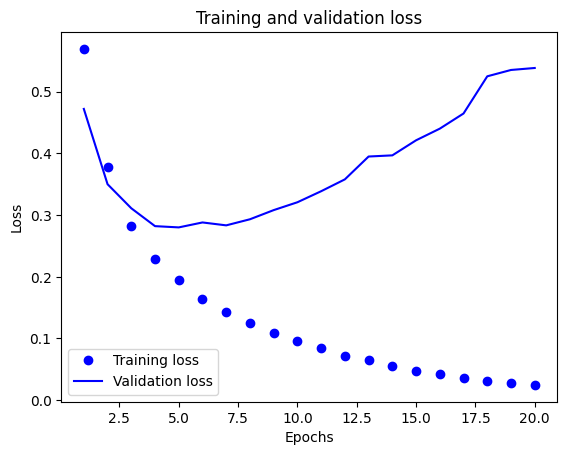

In [ ]:
import matplotlib.pyplot as plt

history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
epochs = range(1, len( history_dict['acc']) + 1)
plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

**3.10 Plotting the training and validation accuracy**

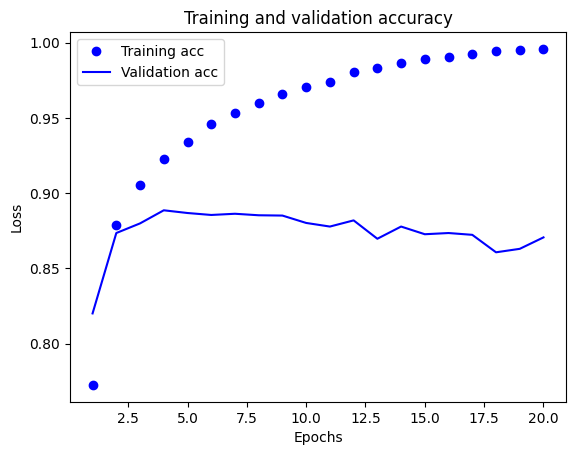

In [ ]:
plt.clf()
acc_values = history_dict['acc']
val_acc_values = history_dict['val_acc']
plt.plot(epochs, acc_values, 'bo', label='Training acc')
plt.plot(epochs, val_acc_values, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

**3.11 Retraining a model from scratch**

to prevent overfitting, you could stop training after three epochs. I

In [ ]:
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=4, batch_size=512)
results = model.evaluate(x_test, y_test)

Epoch 1/4
49/49 [==============================] - 6s 66ms/step - loss: 0.4817 - accuracy: 0.8115
Epoch 2/4
49/49 [==============================] - 4s 76ms/step - loss: 0.2799 - accuracy: 0.9000
Epoch 3/4
49/49 [==============================] - 4s 86ms/step - loss: 0.2155 - accuracy: 0.9225
Epoch 4/4
782/782 [==============================] - 4s 4ms/step - loss: 0.2854 - accuracy: 0.8864


In [ ]:
results

[0.2854253053665161, 0.8864399790763855]

**3.4.5 Using a trained network to generate predictions on new data**

In [ ]:
 model.predict(x_test)

782/782 [==============================] - 2s 3ms/step


array([[0.23125929],
       [0.9998783 ],
       [0.8471697 ],
       ...,
       [0.09423957],
       [0.06743722],
       [0.7123329 ]], dtype=float32)

**3.4.6 Further experiment**

- You used two hidden layers. Try using one or three hidden layers, and see how
doing so affects validation and test accuracy.


In [ ]:
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=4, batch_size=512)
results = model.evaluate(x_test, y_test)

Epoch 1/4
49/49 [==============================] - 4s 31ms/step - loss: 0.4907 - accuracy: 0.7974
Epoch 2/4
49/49 [==============================] - 2s 31ms/step - loss: 0.2795 - accuracy: 0.9000
Epoch 3/4
49/49 [==============================] - 1s 30ms/step - loss: 0.2149 - accuracy: 0.9223
Epoch 4/4
782/782 [==============================] - 7s 9ms/step - loss: 0.2878 - accuracy: 0.8873


In [ ]:
results

[0.2878451347351074, 0.8872799873352051]

- Try using layers with more hidden units or fewer hidden units: 32 units, 64 units,and so on.

In [ ]:
model = models.Sequential()
model.add(layers.Dense(32, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(32, activation='relu'))
model.add(layers.Dense(32, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=4, batch_size=512)
results = model.evaluate(x_test, y_test)

Epoch 1/4
49/49 [==============================] - 3s 46ms/step - loss: 0.4623 - accuracy: 0.7998
Epoch 2/4
49/49 [==============================] - 2s 48ms/step - loss: 0.2585 - accuracy: 0.9036
Epoch 3/4
49/49 [==============================] - 2s 35ms/step - loss: 0.2095 - accuracy: 0.9204
Epoch 4/4
782/782 [==============================] - 2s 3ms/step - loss: 0.3112 - accuracy: 0.8784


In [ ]:
results

[0.31123432517051697, 0.8784400224685669]

In [ ]:
model = models.Sequential()
model.add(layers.Dense(64, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=4, batch_size=512)
results = model.evaluate(x_test, y_test)

Epoch 1/4
49/49 [==============================] - 5s 80ms/step - loss: 0.4522 - accuracy: 0.7873
Epoch 2/4
49/49 [==============================] - 3s 52ms/step - loss: 0.2645 - accuracy: 0.8962
Epoch 3/4
49/49 [==============================] - 2s 50ms/step - loss: 0.2084 - accuracy: 0.9202
Epoch 4/4
782/782 [==============================] - 3s 4ms/step - loss: 0.3602 - accuracy: 0.8609


In [ ]:
results

[0.3602289855480194, 0.8608800172805786]

- Try using the mse loss function instead of binary_crossentropy.

In [ ]:
model = models.Sequential()
model.add(layers.Dense(64, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))
model.compile(optimizer='rmsprop', loss='mse', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=4, batch_size=512)
results = model.evaluate(x_test, y_test)

Epoch 1/4
49/49 [==============================] - 3s 50ms/step - loss: 0.1511 - accuracy: 0.7912
Epoch 2/4
49/49 [==============================] - 2s 49ms/step - loss: 0.0857 - accuracy: 0.8895
Epoch 3/4
49/49 [==============================] - 4s 77ms/step - loss: 0.0688 - accuracy: 0.9121
Epoch 4/4
782/782 [==============================] - 4s 4ms/step - loss: 0.0843 - accuracy: 0.8856


In [ ]:
results

[0.08430156111717224, 0.885640025138855]

- Try using the tanh activation (an activation that was popular in the early days of neural networks) instead of relu

In [ ]:
model = models.Sequential()
model.add(layers.Dense(64, activation='tanh', input_shape=(10000,)))
model.add(layers.Dense(64, activation='tanh'))
model.add(layers.Dense(1, activation='sigmoid'))
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(x_train, y_train, epochs=4, batch_size=512)
results = model.evaluate(x_test, y_test)

Epoch 1/4
49/49 [==============================] - 5s 79ms/step - loss: 0.4174 - accuracy: 0.8134
Epoch 2/4
49/49 [==============================] - 6s 113ms/step - loss: 0.2451 - accuracy: 0.9050
Epoch 3/4
49/49 [==============================] - 2s 50ms/step - loss: 0.2046 - accuracy: 0.9193
Epoch 4/4
782/782 [==============================] - 4s 4ms/step - loss: 0.3214 - accuracy: 0.8768


In [ ]:
results

[0.3213844299316406, 0.8767600059509277]

# **3.5 Classifying newswires: a multiclass classification example**

**3.12 Loading the Reuters dataset**

In [ ]:
from keras.datasets import reuters
(train_data, train_labels), (test_data, test_labels) = reuters.load_data(num_words=10000)

2110848/2110848 [==============================] - 0s 0us/step


As with the IMDB dataset, the argument num_words=10000 restricts the data to the 10,000 most frequently occurring words found in the data.  You have 8,982 training examples and 2,246 test examples:

In [ ]:
len(train_data)

8982

In [ ]:
 len(test_data)

2246

In [ ]:
 train_data[10]

[1,
 245,
 273,
 207,
 156,
 53,
 74,
 160,
 26,
 14,
 46,
 296,
 26,
 39,
 74,
 2979,
 3554,
 14,
 46,
 4689,
 4329,
 86,
 61,
 3499,
 4795,
 14,
 61,
 451,
 4329,
 17,
 12]

**3.13 Decoding newswires back to text**

In [ ]:
word_index = reuters.get_word_index()
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
decoded_newswire = ' '.join([reverse_word_index.get(i - 3, '?') for i in
train_data[0]])

550378/550378 [==============================] - 0s 0us/step


In [ ]:
decoded_newswire

'? ? ? said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net should rise to nine to 10 mln dlrs from six mln dlrs in 1986 and rental operation revenues to 19 to 22 mln dlrs from 12 5 mln dlrs it said cash flow per share this year should be 2 50 to three dlrs reuter 3'

In [ ]:
train_labels[10]

3

 **3.14 Encoding the data**

You can vectorize the data with the one-hot encoder

In [ ]:
import numpy as np
def vectorize_sequences(sequences, dimension=10000):
  results = np.zeros((len(sequences), dimension))
  for i, sequence in enumerate(sequences):
    results[i, sequence] = 1.
  return results


In [ ]:
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

In [ ]:
def to_one_hot(labels, dimension=46):
  results = np.zeros((len(labels), dimension))
  for i, label in enumerate(labels):
    results[i, label] = 1.
  return results


In [ ]:
one_hot_train_labels = to_one_hot(train_labels)
one_hot_test_labels = to_one_hot(test_labels)

Note that there is a built-in way to do this in Keras

In [ ]:
from keras.utils.np_utils import to_categorical

one_hot_train_labels = to_categorical(train_labels)
one_hot_test_labels = to_categorical(test_labels)

In [ ]:
one_hot_train_labels[0]

array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

**3.15 Model definition**

In [ ]:
from keras import models
from keras import layers

In [ ]:
model = models.Sequential()
model.add(layers.Dense(64, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(46, activation='softmax'))

**3.16 Compiling the model**

In [ ]:
model.compile(optimizer='rmsprop',loss='categorical_crossentropy',metrics=['accuracy'])

**3.5.4 Validating your approach**

Let’s set apart 1,000 samples in the training data to use as a validation set.

 **3.17 Setting aside a validation set**

In [ ]:
x_val = x_train[:1000]
partial_x_train = x_train[1000:]
y_val = one_hot_train_labels[:1000]
partial_y_train = one_hot_train_labels[1000:]

**3.18 Training the model**

In [ ]:
history = model.fit(partial_x_train, partial_y_train, epochs=20, batch_size=512, validation_data=(x_val, y_val))

Epoch 1/20
16/16 [==============================] - 6s 36ms/step - loss: 2.7385 - accuracy: 0.4450 - val_loss: 1.8831 - val_accuracy: 0.5810
Epoch 2/20
16/16 [==============================] - 0s 18ms/step - loss: 1.5866 - accuracy: 0.6646 - val_loss: 1.4142 - val_accuracy: 0.6880
Epoch 3/20
16/16 [==============================] - 0s 17ms/step - loss: 1.2167 - accuracy: 0.7375 - val_loss: 1.2268 - val_accuracy: 0.7310
Epoch 4/20
16/16 [==============================] - 0s 20ms/step - loss: 0.9979 - accuracy: 0.7914 - val_loss: 1.1100 - val_accuracy: 0.7440
Epoch 5/20
16/16 [==============================] - 0s 18ms/step - loss: 0.8310 - accuracy: 0.8216 - val_loss: 1.0321 - val_accuracy: 0.7670
Epoch 6/20
16/16 [==============================] - 0s 20ms/step - loss: 0.6905 - accuracy: 0.8530 - val_loss: 0.9573 - val_accuracy: 0.7910
Epoch 7/20
16/16 [==============================] - 0s 17ms/step - loss: 0.5759 - accuracy: 0.8781 - val_loss: 0.9090 - val_accuracy: 0.8060
Epoch 8/20
16

**3.19 Plotting the training and validation loss**

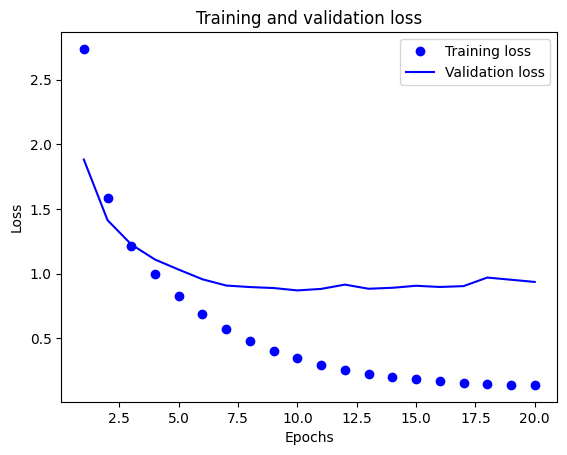

In [ ]:
import matplotlib.pyplot as plt
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

**3.20 Plotting the training and validation accuracy**

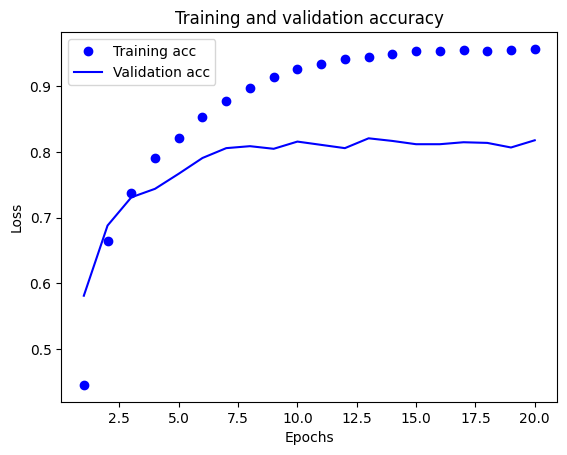

In [ ]:
plt.clf()
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

**PS:**The network begins to overfit after nine epochs. Let’s train a new network from scratch for nine epochs and then evaluate it on the test set

**3.21 Retraining a model from scratch**

In [ ]:
model = models.Sequential()
model.add(layers.Dense(64, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(46, activation='softmax'))
model.compile(optimizer='rmsprop', loss='categorical_crossentropy',metrics=['accuracy'])
model.fit(partial_x_train, partial_y_train,epochs=9,batch_size=512,validation_data=(x_val, y_val))
results = model.evaluate(x_test, one_hot_test_labels)

Epoch 1/9
16/16 [==============================] - 2s 45ms/step - loss: 2.7607 - accuracy: 0.5117 - val_loss: 1.8659 - val_accuracy: 0.6170
Epoch 2/9
16/16 [==============================] - 0s 21ms/step - loss: 1.5540 - accuracy: 0.6751 - val_loss: 1.4056 - val_accuracy: 0.6800
Epoch 3/9
16/16 [==============================] - 0s 24ms/step - loss: 1.1826 - accuracy: 0.7424 - val_loss: 1.1923 - val_accuracy: 0.7410
Epoch 4/9
16/16 [==============================] - 0s 23ms/step - loss: 0.9633 - accuracy: 0.7894 - val_loss: 1.0828 - val_accuracy: 0.7620
Epoch 5/9
16/16 [==============================] - 0s 19ms/step - loss: 0.8032 - accuracy: 0.8282 - val_loss: 0.9978 - val_accuracy: 0.7880
Epoch 6/9
16/16 [==============================] - 0s 18ms/step - loss: 0.6730 - accuracy: 0.8557 - val_loss: 0.9481 - val_accuracy: 0.8100
Epoch 7/9
16/16 [==============================] - 0s 17ms/step - loss: 0.5635 - accuracy: 0.8839 - val_loss: 0.9059 - val_accuracy: 0.8110
Epoch 8/9
16/16 [===

In [ ]:
results

[0.9256619811058044, 0.7858415246009827]

**3.22 Generating predictions for new data**

In [ ]:
predictions = model.predict(x_test)

71/71 [==============================] - 0s 2ms/step


Each entry in predictions is a vector of length 46:

In [ ]:
predictions[0].shape

(46,)

The coefficients in this vector sum to 1:

In [ ]:
np.sum(predictions[0])

1.0000001

The largest entry is the predicted class—the class with the highest probability:

In [ ]:
np.argmax(predictions[0])

3

# **3.6 Predicting house prices: a regression example**

**3.24 Loading the Boston housing dataset**

In [ ]:
from keras.datasets import boston_housing
(train_data, train_targets), (test_data, test_targets) = boston_housing.load_data()

57026/57026 [==============================] - 0s 0us/step


In [ ]:
train_data.shape

(404, 13)

In [ ]:
test_data.shape

(102, 13)

In [ ]:
train_data[:5]

array([[1.23247e+00, 0.00000e+00, 8.14000e+00, 0.00000e+00, 5.38000e-01,
        6.14200e+00, 9.17000e+01, 3.97690e+00, 4.00000e+00, 3.07000e+02,
        2.10000e+01, 3.96900e+02, 1.87200e+01],
       [2.17700e-02, 8.25000e+01, 2.03000e+00, 0.00000e+00, 4.15000e-01,
        7.61000e+00, 1.57000e+01, 6.27000e+00, 2.00000e+00, 3.48000e+02,
        1.47000e+01, 3.95380e+02, 3.11000e+00],
       [4.89822e+00, 0.00000e+00, 1.81000e+01, 0.00000e+00, 6.31000e-01,
        4.97000e+00, 1.00000e+02, 1.33250e+00, 2.40000e+01, 6.66000e+02,
        2.02000e+01, 3.75520e+02, 3.26000e+00],
       [3.96100e-02, 0.00000e+00, 5.19000e+00, 0.00000e+00, 5.15000e-01,
        6.03700e+00, 3.45000e+01, 5.98530e+00, 5.00000e+00, 2.24000e+02,
        2.02000e+01, 3.96900e+02, 8.01000e+00],
       [3.69311e+00, 0.00000e+00, 1.81000e+01, 0.00000e+00, 7.13000e-01,
        6.37600e+00, 8.84000e+01, 2.56710e+00, 2.40000e+01, 6.66000e+02,
        2.02000e+01, 3.91430e+02, 1.46500e+01]])

In [ ]:
train_targets

array([15.2, 42.3, 50. , 21.1, 17.7, 18.5, 11.3, 15.6, 15.6, 14.4, 12.1,
       17.9, 23.1, 19.9, 15.7,  8.8, 50. , 22.5, 24.1, 27.5, 10.9, 30.8,
       32.9, 24. , 18.5, 13.3, 22.9, 34.7, 16.6, 17.5, 22.3, 16.1, 14.9,
       23.1, 34.9, 25. , 13.9, 13.1, 20.4, 20. , 15.2, 24.7, 22.2, 16.7,
       12.7, 15.6, 18.4, 21. , 30.1, 15.1, 18.7,  9.6, 31.5, 24.8, 19.1,
       22. , 14.5, 11. , 32. , 29.4, 20.3, 24.4, 14.6, 19.5, 14.1, 14.3,
       15.6, 10.5,  6.3, 19.3, 19.3, 13.4, 36.4, 17.8, 13.5, 16.5,  8.3,
       14.3, 16. , 13.4, 28.6, 43.5, 20.2, 22. , 23. , 20.7, 12.5, 48.5,
       14.6, 13.4, 23.7, 50. , 21.7, 39.8, 38.7, 22.2, 34.9, 22.5, 31.1,
       28.7, 46. , 41.7, 21. , 26.6, 15. , 24.4, 13.3, 21.2, 11.7, 21.7,
       19.4, 50. , 22.8, 19.7, 24.7, 36.2, 14.2, 18.9, 18.3, 20.6, 24.6,
       18.2,  8.7, 44. , 10.4, 13.2, 21.2, 37. , 30.7, 22.9, 20. , 19.3,
       31.7, 32. , 23.1, 18.8, 10.9, 50. , 19.6,  5. , 14.4, 19.8, 13.8,
       19.6, 23.9, 24.5, 25. , 19.9, 17.2, 24.6, 13

**3.25 Normalizing the data**

In [ ]:
mean = train_data.mean(axis=0)
train_data -= mean
std = train_data.std(axis=0)
train_data /= std
test_data -= mean
test_data /= std

In [ ]:
train_data[:5]

array([[1.23247e+00, 0.00000e+00, 8.14000e+00, 0.00000e+00, 5.38000e-01,
        6.14200e+00, 9.17000e+01, 3.97690e+00, 4.00000e+00, 3.07000e+02,
        2.10000e+01, 3.96900e+02, 1.87200e+01],
       [2.17700e-02, 8.25000e+01, 2.03000e+00, 0.00000e+00, 4.15000e-01,
        7.61000e+00, 1.57000e+01, 6.27000e+00, 2.00000e+00, 3.48000e+02,
        1.47000e+01, 3.95380e+02, 3.11000e+00],
       [4.89822e+00, 0.00000e+00, 1.81000e+01, 0.00000e+00, 6.31000e-01,
        4.97000e+00, 1.00000e+02, 1.33250e+00, 2.40000e+01, 6.66000e+02,
        2.02000e+01, 3.75520e+02, 3.26000e+00],
       [3.96100e-02, 0.00000e+00, 5.19000e+00, 0.00000e+00, 5.15000e-01,
        6.03700e+00, 3.45000e+01, 5.98530e+00, 5.00000e+00, 2.24000e+02,
        2.02000e+01, 3.96900e+02, 8.01000e+00],
       [3.69311e+00, 0.00000e+00, 1.81000e+01, 0.00000e+00, 7.13000e-01,
        6.37600e+00, 8.84000e+01, 2.56710e+00, 2.40000e+01, 6.66000e+02,
        2.02000e+01, 3.91430e+02, 1.46500e+01]])

# **3.6.3 Building your network**

**3.26 Model definition**

In [ ]:
from keras import models
from keras import layers
def build_model():
  model = models.Sequential()
  model.add(layers.Dense(64, activation='relu',   input_shape=(train_data.shape[1],)))
  model.add(layers.Dense(64, activation='relu'))
  model.add(layers.Dense(1))
  model.compile(optimizer='rmsprop', loss='mse', metrics=['mae'])
  return model

In [ ]:
train_data[1].shape

(13,)

In [ ]:
train_data.shape[1]

13

**3.27 K-fold validation**

In [ ]:
import numpy as np
k=4
num_val_samples = len(train_data) // k
num_epochs = 100
all_scores = []
for i in range(k):
  print('processing fold #', i)
  val_data = train_data[i * num_val_samples: (i + 1) * num_val_samples]
  val_targets = train_targets[i * num_val_samples: (i + 1) * num_val_samples]
  partial_train_data = np.concatenate(  [train_data[:i * num_val_samples],  train_data[(i + 1) * num_val_samples:]],  axis=0)
  partial_train_targets = np.concatenate(  [train_targets[:i * num_val_samples],  train_targets[(i + 1) * num_val_samples:]],  axis=0)
  model = build_model()
  model.fit(partial_train_data, partial_train_targets,   epochs=num_epochs, batch_size=1, verbose=0)
  val_mse, val_mae = model.evaluate(val_data, val_targets, verbose=0)
  all_scores.append(val_mae)

processing fold # 0
processing fold # 1
processing fold # 2
processing fold # 3


In [ ]:
all_scores

[2.085780382156372, 2.2659566402435303, 2.7801661491394043, 2.3969357013702393]

In [ ]:
np.mean(all_scores)

2.3822097182273865